In [3]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek


In [4]:
from utils import *

In [5]:
# Download data
df = pd.read_csv('../data/workable_data.csv')

In [53]:
print(df.shape)
df.head()

(1516948, 20)


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,Pressure_switch,Oil_level,Caudal_impulses,day,month,hour,minute,second,failure
0,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,0,0
1,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,10,0
2,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,19,0
3,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,29,0
4,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,39,0


In [6]:
# Select target and features
X = df.drop('failure', axis=1)
y = df['failure']


# Chronological Split + threshold prediction

In [7]:
# Split the data in a way that the test data contains 1 of the failures and the train 3 of the failures
split_index = int(len(df) * 0.7)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [56]:
# make sure test data contain failure values
print(y_test.unique())
X_test.head()

[0 1]


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,Pressure_switch,Oil_level,Caudal_impulses,day,month,hour,minute,second
1061863,-0.01,8.462,8.450,-0.018,8.466,64.800,0.0375,1.0,0.0,1.0,1.0,1.0,1.0,1.0,29,6,16,18,17
1061864,-0.01,8.448,8.436,-0.016,8.452,64.825,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,29,6,16,18,27
1061865,-0.01,8.436,8.426,-0.016,8.438,64.625,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,29,6,16,18,37
1061866,-0.01,8.424,8.414,-0.016,8.426,64.550,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,29,6,16,18,47
1061867,-0.01,8.412,8.402,-0.016,8.412,64.475,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,29,6,16,18,57


In [57]:
#Fit the model
rf = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
# Lower threshold to 0.15 to increase recall — catch more failures at the cost of precision
y_prob = rf.predict_proba(X_test)[:, 1]
# Default threshold is 0.5 — too strict for rare failures. 
# Prioritizes Recall (catching real failures) over Precision (avoiding false alarms)
# At 0.15, we flag failure if model is ≥15% confident
y_pred = (y_prob >= 0.15).astype(int) 
print("Rando Forest Report:\n", classification_report(y_test, y_pred, zero_division=0))

Rando Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    453463
           1       0.52      0.50      0.51      1622

    accuracy                           1.00    455085
   macro avg       0.76      0.75      0.75    455085
weighted avg       1.00      1.00      1.00    455085



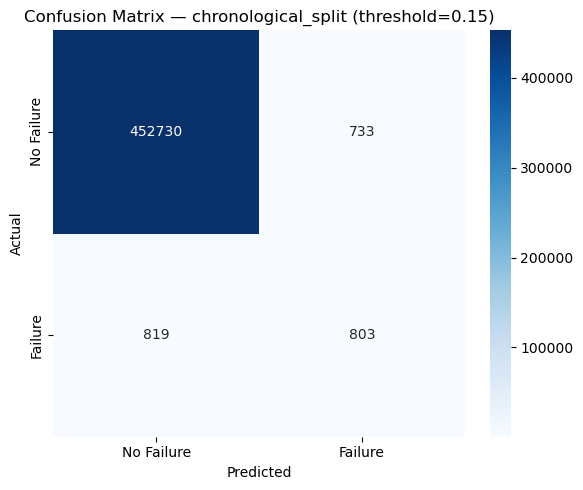

In [59]:
results = evaluate_model(
    rf, 
    X_train, 
    X_test, 
    y_train, 
    y_test, 
    'chronological_split', 
    'chronological split, '
    'threshold 0.15', 
    0.15
)

In [60]:
results

,experiment_name,explanation,model,threshold,F1_Train(Class1),F1_Test(Class1),Precision_Test,Recall_Test(Class1),Overfit_Gap(F1),ROC_AUC
0,chronological_split,"chronological split, threshold 0.15",RandomForestClassifier,0.15,0.9976,0.5085,0.5228,0.4951,0.489,0.9973


### Conclutions   
- For splitting the data we need also failures on the train data. That is why we splited it in a chronological way.
- We need to use threshold lower than 0,5 when predicting, at the cost of more false alarms
- The recall on the class 1 is the most important metric in this case (0,5), because indicates how many real failures we catchet out of all real failures

# Udersample 50/50 failure on train data

In [61]:
# 1.0 = 50/50 balance between normal and failure rows
rus = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print(f"BEFORE undersampling → Normal: {sum(y_train == 0):,} | Failures: {sum(y_train == 1):,}")
print(f"AFTER  undersampling → Normal: {sum(y_train_res == 0):,} | Failures: {sum(y_train_res == 1):,}")

BEFORE undersampling → Normal: 1,033,531 | Failures: 28,332
AFTER  undersampling → Normal: 28,332 | Failures: 28,332


In [ ]:
# Fit the model
rf_res = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_res.fit(X_train_res, y_train_res)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_prob = rf_res.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.15).astype(int)

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    453463
           1       0.27      0.74      0.40      1622

    accuracy                           0.99    455085
   macro avg       0.64      0.86      0.70    455085
weighted avg       1.00      0.99      0.99    455085



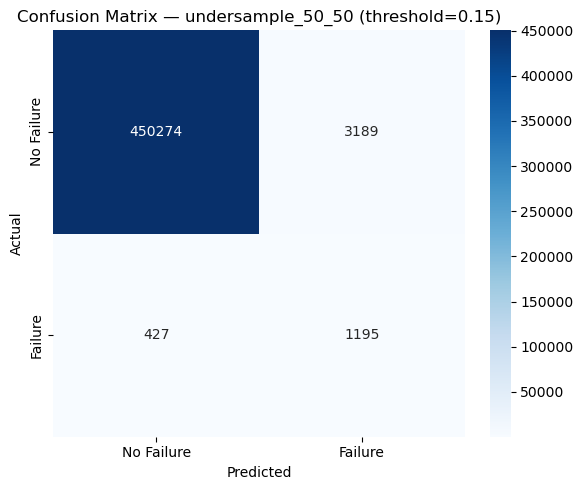

In [ ]:
results = evaluate_model(
    rf_res,
    X_train_res, 
    X_test,    
    y_train_res, 
    y_test,
    'undersample_50_50',
    'chronological split + 50/50 undersampling + threshold 0.15',
    threshold=0.15
)

In [65]:
results

,experiment_name,explanation,model,threshold,F1_Train(Class1),F1_Test(Class1),Precision_Test,Recall_Test(Class1),Overfit_Gap(F1),ROC_AUC
0,undersample_50_50,chronological split + 50/50 undersampling + th...,RandomForestClassifier,0.15,0.9997,0.3979,0.2726,0.7367,0.6018,0.9934


### Conclutions  
- The model improved Recall score significatly
- At the cost of a big increase of false alarms and a bit more of overfitting


# Udersample 70/30 failure on train data
$sampling\_strategy = \frac{minority}{majority}=\frac{30}{70}\approx 0.4286$

In [ ]:
# Undersampling
rus = RandomUnderSampler(sampling_strategy=0.4286, random_state=42)
X_train_res70, y_train_res70 = rus.fit_resample(X_train, y_train)

In [12]:
# Fit the model
rf_res70 = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_res70.fit(X_train_res70, y_train_res70)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
y_prob = rf_res70.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.15).astype(int)

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    453463
           1       0.30      0.73      0.42      1622

    accuracy                           0.99    455085
   macro avg       0.65      0.86      0.71    455085
weighted avg       1.00      0.99      0.99    455085



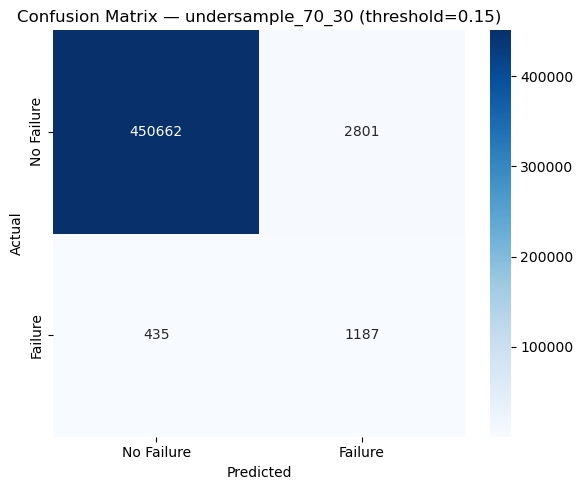

In [ ]:
results = evaluate_model(
    rf_res70,
    X_train_res70, 
    X_test,    
    y_train_res70, 
    y_test,
    'undersample_70_30',
    'chronological split + 70/30 undersampling + threshold 0.15',
    threshold=0.15
)

In [10]:
results

,experiment_name,explanation,model,threshold,F1_Train(Class1),F1_Test(Class1),Precision_Test,Recall_Test(Class1),Overfit_Gap(F1),ROC_AUC
0,undersample_70_30,chronological split + 70/30 undersampling + th...,RandomForestClassifier,0.15,0.9996,0.4283,0.3021,0.7355,0.5714,0.996


## Conclusions
- Recall droped a bit but the Precision and F1 scores improved
- Less false alarms, 2 more false positives
- Less overfiting
- In general this split improves the model

# Oversampling with SMOTE

In [ ]:
# SMOTE creates synthetic failure rows by interpolating between real ones

# strategy = failures / normals
# 0.05  →  1 failure per 20 normals  (barely changes anything)
# 0.1   →  1 failure per 10 normals
# 0.5   →  1 failure per 2 normals   
# 1.0   →  1 failure per 1 normal    (perfect 50/50)

for strategy in [0.05, 0.1, 0.5, 1.0]:
    smote = SMOTE(sampling_strategy=strategy, random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    
    rf_temp = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
    rf_temp.fit(X_res, y_res)
    
    y_prob = rf_temp.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.15).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    print(f"strategy={strategy} → Precision: {report['1']['precision']:.3f} | Recall: {report['1']['recall']:.3f} | F1: {report['1']['f1-score']:.3f}")


| Strategy | Precision | Recall | F1 |
--- | --- | --- | ---
|  0.05 | Precision: 0.586 | Recall: 0.691 | F1: 0.634 | 
| 0.1 | Precision: 0.592 | Recall: 0.616 | F1: 0.604  |
|  0.5 | Precision: 0.626 | Recall: 0.567 | F1: 0.595  |
|  1.0 | Precision: 0.600 | Recall: 0.520 | F1: 0.557  |

In [17]:
# I chose sampling_strategy = 0.05 because is the biggest Recall
smote = SMOTE(sampling_strategy=0.05, random_state=42) 
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [18]:
# Fit the model
rf_sm = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_sm.fit(X_train_sm, y_train_sm)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


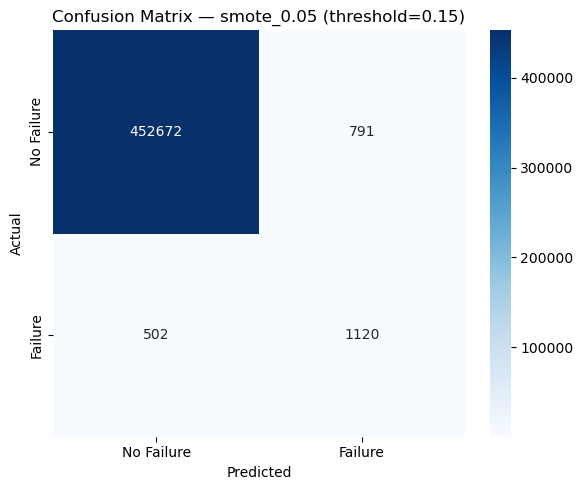

In [19]:
results = evaluate_model(
    rf_sm,
    X_train_sm, X_test,
    y_train_sm, y_test,
    'smote_0.05',
    'chronological split + SMOTE sampling_strategy=0.0.5 + threshold 0.15',
    threshold=0.15
)

In [20]:
results

,experiment_name,explanation,model,threshold,F1_Train(Class1),F1_Test(Class1),Precision_Test,Recall_Test(Class1),Overfit_Gap(F1),ROC_AUC
0,smote_0.05,chronological split + SMOTE sampling_strategy=...,RandomForestClassifier,0.15,0.9987,0.634,0.5861,0.6905,0.3646,0.9959


## Conclutions  
- Recall dropped but it is still good
- F1 Precision and overfit gap improved draastically

# SMOTETomek  
SMOTE → oversamples the minority class by creating synthetic samples  
Tomek Links → cleans the border between classes by removing overlapping/ambiguous samples from the majority class

In [ ]:
# SMOTE creates synthetic failure rows by interpolating between real ones

# strategy = failures / normals
# 0.05  →  1 failure per 20 normals  
# 0.1   →  1 failure per 10 normals
# 0.5   →  1 failure per 2 normals   
# 1.0   →  1 failure per 1 normal  

for strategy in [0.05, 0.1, 0.5, 1.0]:
    smote = SMOTETomek(sampling_strategy=strategy, random_state=42, n_jobs=-1)
    X_s, y_s = smote.fit_resample(X_train, y_train)
    
    rf_temp = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
    rf_temp.fit(X_s, y_s)
    
    y_prob = rf_temp.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.15).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    print(f"strategy={strategy} | Precision: {report['1']['precision']:.3f} | Recall: {report['1']['recall']:.3f} | F1: {report['1']['f1-score']:.3f}")


In [8]:
smt = SMOTETomek(sampling_strategy=0.05, random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)
print(pd.Series(y_train_smt).value_counts())

failure
0    1033529
1      51674
Name: count, dtype: int64


In [9]:
rf_smt = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_smt.fit(X_train_smt, y_train_smt)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


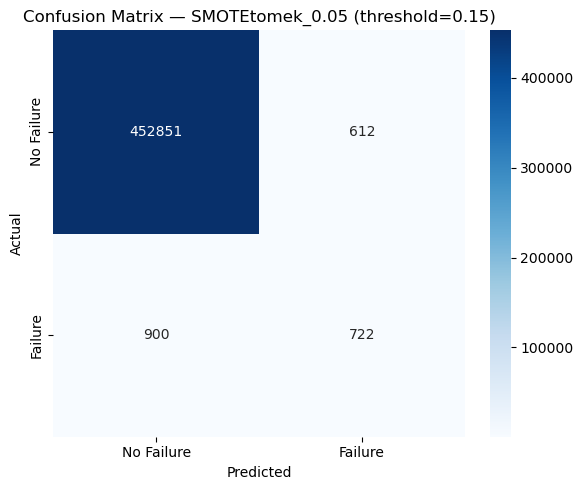

In [10]:
results = evaluate_model(
    rf_smt,
    X_train_smt, X_test,
    y_train_smt, y_test,
    'SMOTEtomek_0.05',
    'chronological split + SMOTEtomek sampling_strategy=0.0.5 + threshold=0.15',
    threshold=0.15
)

## Conclution 
It is worse overall